# HDAC8 QSAR models (RDKit 2D descriptors)

Regression models for HDAC8 pChEMBL on the scaffold-split sets `HDAC8_train.sdf` and `HDAC8_test.sdf`.

Descriptors: RDKit 2D physicochemical descriptors (`rdkit.Chem.Descriptors`). Hyperparameters are tuned with **Optuna** (TPE + median pruning) instead of `GridSearchCV`.


## 1. Imports and settings


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import optuna
from IPython.display import display
import ipywidgets as widgets
from catboost import CatBoostRegressor
from molvs import standardize_smiles
from rdkit import Chem, RDLogger
from rdkit.Chem import Descriptors
from rdkit.ML.Descriptors import MoleculeDescriptors
from sklearn.base import clone
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.model_selection import KFold, cross_val_predict, permutation_test_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

RDLogger.DisableLog("rdApp.*")
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42
ACTIVITY_PROP = "pchembl_value_mean"
TRAIN_SDF = Path("HDAC8_train.sdf")
TEST_SDF = Path("HDAC8_test.sdf")
MODEL_DIR = Path("models/RDKit")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Ipc frequently overflows for larger molecules and is dropped a priori.
DESC_SKIP = {"Ipc"}
AD_Z = 0.5

# Set True for a short debug run.
QUICK_RUN = False
N_SPLITS_SEARCH = 3 if QUICK_RUN else 5
N_TRIALS = {
    "CatBoost": 8 if QUICK_RUN else 40,
    "SVR": 8 if QUICK_RUN else 35,
    "MLP": 6 if QUICK_RUN else 25,
    "kNN": 8 if QUICK_RUN else 25,
}
N_PERMUTATIONS = 5 if QUICK_RUN else 20

cv_search = KFold(n_splits=N_SPLITS_SEARCH, shuffle=True, random_state=SEED)
cv_final = KFold(n_splits=5, shuffle=True, random_state=SEED)
rng = np.random.RandomState(SEED)


## 2. Data loading and curation

Molecules are sanitized and standardized with MolVS. Failed structures are dropped together with their activity values. The endpoint is `pchembl_value_mean` from the revision SDF files.


In [2]:
def load_sdf(path, activity_prop=ACTIVITY_PROP):
    supplier = Chem.ForwardSDMolSupplier(str(path), sanitize=False)
    rows, failed = [], []

    for i, mol in enumerate(supplier):
        rec = {"index": i + 1}
        if mol is None:
            failed.append({**rec, "reason": "unreadable record"})
            continue

        rec["chembl_id"] = mol.GetProp("molecule_chembl_id") if mol.HasProp("molecule_chembl_id") else f"mol_{i+1}"
        rec["smiles_raw"] = (
            mol.GetProp("canonical_smiles") if mol.HasProp("canonical_smiles") else Chem.MolToSmiles(mol)
        )
        rec["scaffold"] = mol.GetProp("scaffold") if mol.HasProp("scaffold") else ""
        try:
            rec["y"] = float(mol.GetProp(activity_prop))
        except Exception as exc:
            failed.append({**rec, "reason": f"missing/invalid {activity_prop}: {exc}"})
            continue

        try:
            Chem.SanitizeMol(mol)
            std_smi = standardize_smiles(Chem.MolToSmiles(mol))
            std_mol = Chem.MolFromSmiles(std_smi)
            if std_mol is None:
                raise ValueError("MolFromSmiles returned None after standardization")
        except Exception as exc:
            failed.append({**rec, "reason": str(exc)})
            continue

        rec.update({"mol": std_mol, "smiles": std_smi})
        rows.append(rec)

    data = pd.DataFrame(rows)
    failed = pd.DataFrame(failed)
    print(f"{path.name}: kept {len(data)} / {len(data) + len(failed)} molecules ({len(failed)} failed)")
    return data, failed


train_df, train_failed = load_sdf(TRAIN_SDF)
test_df, test_failed = load_sdf(TEST_SDF)

display(train_failed if len(train_failed) else "No failed training molecules")
display(test_failed if len(test_failed) else "No failed test molecules")


HDAC8_train.sdf: kept 2092 / 2092 molecules (0 failed)
HDAC8_test.sdf: kept 524 / 524 molecules (0 failed)


'No failed training molecules'

'No failed test molecules'

Train: n = 2092, pChEMBL = 6.049 ± 0.883 [4.02, 9.92], scaffolds = 1
Test: n = 524, pChEMBL = 6.051 ± 0.895 [4.01, 9.99], scaffolds = 1
Shared Murcko scaffolds: 0


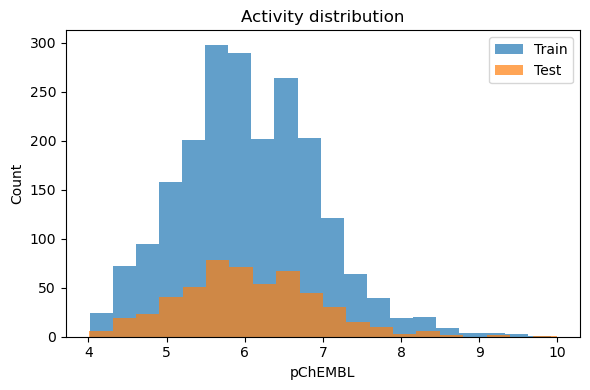

,index,chembl_id,smiles_raw,scaffold,y,mol,smiles
0,1,CHEMBL1767046,CNC(=O)/C(CCCCC[C@H](NCc1ccc(OC)cc1)C(=O)Nc1cc...,,4.02,<rdkit.Chem.rdchem.Mol object at 0x000001D1417...,CNC(=O)/C(CCCCC[C@H](NCc1ccc(OC)cc1)C(=O)Nc1cc...
1,2,CHEMBL1469,O=C(O)CCCc1ccccc1,,4.03,<rdkit.Chem.rdchem.Mol object at 0x000001D1417...,O=C(O)CCCc1ccccc1
2,3,CHEMBL3605493,Nc1ccccc1NC(=O)c1ccc(CSC2=N[C@@H](Cc3ccccc3)CO...,,4.06,<rdkit.Chem.rdchem.Mol object at 0x000001D1417...,Nc1ccccc1NC(=O)c1ccc(CSC2=N[C@@H](Cc3ccccc3)CO...
3,4,CHEMBL1767047,CNC(=O)/C(CCCCC[C@@H](C(=O)Nc1ccccc1)N(Cc1cccc...,,4.06,<rdkit.Chem.rdchem.Mol object at 0x000001D1417...,CNC(=O)/C(CCCCC[C@@H](C(=O)Nc1ccccc1)N(Cc1cccc...
4,5,CHEMBL3605499,Nc1ccccc1NC(=O)c1ccc(CNC2=N[C@@H](c3ccc(O)cc3)...,,4.08,<rdkit.Chem.rdchem.Mol object at 0x000001D1417...,Nc1ccccc1NC(=O)c1ccc(CNC2=N[C@@H](c3ccc(O)cc3)...


In [3]:
def summarize_split(name, df):
    print(
        f"{name}: n = {len(df)}, "
        f"pChEMBL = {df['y'].mean():.3f} ± {df['y'].std():.3f} "
        f"[{df['y'].min():.2f}, {df['y'].max():.2f}], "
        f"scaffolds = {df['scaffold'].nunique()}"
    )


summarize_split("Train", train_df)
summarize_split("Test", test_df)

shared = set(train_df["scaffold"]) & set(test_df["scaffold"])
shared.discard("")
print("Shared Murcko scaffolds:", len(shared))
if shared:
    raise AssertionError("Scaffold leakage between train and test.")

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(train_df["y"], bins=20, alpha=0.7, label="Train")
ax.hist(test_df["y"], bins=20, alpha=0.7, label="Test")
ax.set_xlabel("pChEMBL")
ax.set_ylabel("Count")
ax.set_title("Activity distribution")
ax.legend()
plt.tight_layout()
plt.show()

train_df.head()


## 3. RDKit 2D descriptors

All 2D descriptors from `rdkit.Chem.Descriptors.descList` except `Ipc`. Non-finite values are treated as missing. Columns that are missing or constant on the **training** set are removed; the identical column set is used for the test set. Remaining test-set NaNs (if any) are filled with the training median.


In [4]:
DESC_NAMES_ALL = [name for name, _ in Descriptors.descList if name not in DESC_SKIP]
desc_calc = MoleculeDescriptors.MolecularDescriptorCalculator(DESC_NAMES_ALL)


def rdkit_descriptors(mols):
    rows = [desc_calc.CalcDescriptors(mol) for mol in mols]
    X = np.asarray(rows, dtype=np.float64)
    X[~np.isfinite(X)] = np.nan
    return X


X_tr_raw = rdkit_descriptors(train_df["mol"])
X_ts_raw = rdkit_descriptors(test_df["mol"])
desc_tr = pd.DataFrame(X_tr_raw, columns=DESC_NAMES_ALL)
desc_ts = pd.DataFrame(X_ts_raw, columns=DESC_NAMES_ALL)

nan_cols = desc_tr.columns[desc_tr.isna().any()].tolist()
const_cols = desc_tr.columns[desc_tr.std(ddof=0) == 0].tolist()
drop_cols = sorted(set(nan_cols) | set(const_cols))
desc_names = [c for c in DESC_NAMES_ALL if c not in drop_cols]

X_tr = desc_tr[desc_names].to_numpy(dtype=np.float64)
X_ts = desc_ts[desc_names].to_numpy(dtype=np.float64)
y_tr = train_df["y"].to_numpy(dtype=np.float64)
y_ts = test_df["y"].to_numpy(dtype=np.float64)

if np.isnan(X_ts).any():
    med = np.nanmedian(X_tr, axis=0)
    nan_mask = np.isnan(X_ts)
    X_ts[nan_mask] = np.take(med, np.where(nan_mask)[1])

print(f"RDKit descriptors available: {len(DESC_NAMES_ALL)}")
print(f"Dropped (NaN on train): {len(nan_cols)}; dropped (constant on train): {len(const_cols)}")
print("X_train:", X_tr.shape, "X_test:", X_ts.shape)
if drop_cols:
    print("Dropped columns:", ", ".join(drop_cols))

pd.Series(desc_names, name="descriptor").to_csv(MODEL_DIR / "descriptor_names.csv", index=False)
np.savetxt(MODEL_DIR / "x_tr_RDKit.csv", X_tr, delimiter=",")
np.savetxt(MODEL_DIR / "x_ts_RDKit.csv", X_ts, delimiter=",")
np.savetxt(MODEL_DIR / "y_tr.csv", y_tr, delimiter=",")
np.savetxt(MODEL_DIR / "y_ts.csv", y_ts, delimiter=",")


RDKit descriptors available: 216
Dropped (NaN on train): 0; dropped (constant on train): 14
X_train: (2092, 202) X_test: (524, 202)
Dropped columns: NumRadicalElectrons, SMR_VSA8, SlogP_VSA9, fr_azo, fr_barbitur, fr_diazo, fr_epoxide, fr_isocyan, fr_isothiocyan, fr_nitroso, fr_phos_acid, fr_phos_ester, fr_quatN, fr_thiocyan


## 4. Shared utilities

OECD-style metrics: R² on the training set, Q² from cross-validation, and external R² on the held-out scaffold test set.

**Applicability domain (AD).** RDKit descriptors are continuous and live on different scales, so nearest-neighbour comparison is done after `StandardScaler` is fit on the training set. The distance is Euclidean:

$$D_{\mathrm{Euclidean}}(a,b) = \lVert z(a) - z(b) \rVert_2$$

where $z(\cdot)$ is the training-set z-score. The AD threshold is $\bar{d} + 0.5\,\sigma$ of the nearest-neighbour distances in the training set (k = 1). A query is inside the domain if its nearest training neighbour satisfies $D_{\mathrm{Euclidean}} \le d_{\mathrm{limit}}$.

In-AD membership only means the compound is close to the training descriptor space. It is **not** proof that an individual prediction is reliable: in-AD compounds can still be mispredicted, and AD-filtered statistics describe the interpolative subset only.

Test-set predictions are appended to `models/RDKit/test_predictions.csv` immediately after each model is evaluated.


In [5]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def ccc(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mean_t, mean_p = y_true.mean(), y_pred.mean()
    var_t, var_p = y_true.var(), y_pred.var()
    cov = np.mean((y_true - mean_t) * (y_pred - mean_p))
    denom = var_t + var_p + (mean_t - mean_p) ** 2
    return float(2 * cov / denom) if denom else np.nan


def regression_metrics(y_true, y_pred):
    return {
        "R2": float(r2_score(y_true, y_pred)),
        "RMSE": rmse(y_true, y_pred),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "CCC": ccc(y_true, y_pred),
    }


def compute_ad(X_train, z=AD_Z):
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X_train)
    dist = euclidean_distances(Xs)
    np.fill_diagonal(dist, np.inf)
    nn = dist.min(axis=1)
    limit = float(nn.mean() + z * nn.std(ddof=0))
    return limit, nn, scaler


def apply_ad(X_train, X_test, limit, scaler):
    Xs_tr = scaler.transform(X_train)
    Xs_ts = scaler.transform(X_test)
    dist = euclidean_distances(Xs_ts, Xs_tr)
    nn = dist.min(axis=1)
    return nn <= limit, nn


def plot_obs_pred(y_true, y_pred, title, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(4.2, 4.2))
    lo = min(y_true.min(), y_pred.min()) - 0.2
    hi = max(y_true.max(), y_pred.max()) + 0.2
    ax.scatter(y_true, y_pred, s=16, alpha=0.65, edgecolors="none")
    ax.plot([lo, hi], [lo, hi], color="black", lw=1)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_xlabel("Observed pChEMBL")
    ax.set_ylabel("Predicted pChEMBL")
    ax.set_title(title)
    ax.set_aspect("equal", adjustable="box")
    return ax


def cv_r2_pruned(trial, factory, X, y, cv, fit_params=None):
    fit_params = fit_params or {}
    scores = []
    for step, (tr_idx, va_idx) in enumerate(cv.split(X, y)):
        model = factory()
        model.fit(X[tr_idx], y[tr_idx], **fit_params)
        pred = model.predict(X[va_idx])
        scores.append(r2_score(y[va_idx], pred))
        trial.report(float(np.mean(scores)), step)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return float(np.mean(scores))


def run_study(name, objective, n_trials):
    sampler = optuna.samplers.TPESampler(seed=SEED)
    pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=1)
    study = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner, study_name=name)

    # Optuna's tqdm.notebook bar often fails in Jupyter Notebook 7
    # ("Error displaying widget: model not found"). Use core ipywidgets instead.
    bar = widgets.IntProgress(value=0, min=0, max=n_trials, description=name, bar_style="info")
    label = widgets.HTML(value="starting&hellip;")
    display(widgets.HBox([bar, label]))

    def on_trial(study, trial):
        bar.value = len(study.trials)
        if trial.state.name == "PRUNED":
            label.value = f"trial {trial.number} pruned; best CV R² = {study.best_value:.4f}"
        elif trial.value is not None:
            label.value = (
                f"trial {trial.number}: CV R² = {trial.value:.4f}; "
                f"best = {study.best_value:.4f} (trial {study.best_trial.number})"
            )
        if bar.value >= n_trials:
            bar.bar_style = "success"

    study.optimize(objective, n_trials=n_trials, show_progress_bar=False, callbacks=[on_trial])
    print(f"{name}: best CV R2 = {study.best_value:.4f}")
    print("Best params:", study.best_params)
    return study


def evaluate_model(name, estimator, X_tr, y_tr, X_ts, y_ts, in_ad, fit_params=None, cv_fit_params=None):
    fit_params = fit_params or {}
    cv_fit_params = cv_fit_params or {}
    model = clone(estimator)
    model.fit(X_tr, y_tr, **fit_params)

    y_hat_tr = model.predict(X_tr)
    y_hat_cv = cross_val_predict(clone(estimator), X_tr, y_tr, cv=cv_final, n_jobs=1, params=cv_fit_params)
    y_hat_ts = model.predict(X_ts)

    train_m = regression_metrics(y_tr, y_hat_tr)
    cv_m = regression_metrics(y_tr, y_hat_cv)
    test_m = regression_metrics(y_ts, y_hat_ts)

    coverage = float(in_ad.mean()) if len(in_ad) else np.nan
    if in_ad.any():
        ad_m = regression_metrics(y_ts[in_ad], y_hat_ts[in_ad])
    else:
        ad_m = {k: np.nan for k in test_m}

    row = {
        "model": name,
        "R2_train": train_m["R2"],
        "RMSE_train": train_m["RMSE"],
        "Q2_CV": cv_m["R2"],
        "RMSE_CV": cv_m["RMSE"],
        "MAE_CV": cv_m["MAE"],
        "R2_ext": test_m["R2"],
        "RMSE_ext": test_m["RMSE"],
        "MAE_ext": test_m["MAE"],
        "CCC_ext": test_m["CCC"],
        "R2_ext_AD": ad_m["R2"],
        "RMSE_ext_AD": ad_m["RMSE"],
        "AD_coverage": coverage,
    }

    print(pd.Series(row).to_string())
    fig, axes = plt.subplots(1, 3, figsize=(12.5, 4.0))
    plot_obs_pred(y_tr, y_hat_tr, f"{name} train  R2={train_m['R2']:.3f}", ax=axes[0])
    plot_obs_pred(y_tr, y_hat_cv, f"{name} 5-fold CV  Q2={cv_m['R2']:.3f}", ax=axes[1])
    plot_obs_pred(y_ts, y_hat_ts, f"{name} test  R2={test_m['R2']:.3f}", ax=axes[2])
    if (~in_ad).any():
        axes[2].scatter(
            y_ts[~in_ad],
            y_hat_ts[~in_ad],
            s=28,
            facecolors="none",
            edgecolors="crimson",
            label="outside training space (AD)",
        )
        axes[2].legend(loc="lower right", fontsize=8)
    plt.tight_layout()
    plt.show()
    write_test_predictions(name, y_hat_ts)
    return model, row, {"train": y_hat_tr, "cv": y_hat_cv, "test": y_hat_ts}


def write_test_predictions(name, y_hat_ts):
    pred_table[f"pred_{name}"] = np.asarray(y_hat_ts)
    pred_table.to_csv(MODEL_DIR / "test_predictions.csv", index=False)
    print(f"Updated {MODEL_DIR / 'test_predictions.csv'} with pred_{name}")
    cols = ["chembl_id", "pchembl_obs", f"pred_{name}", "in_AD", "D_Euclidean"]
    display(pred_table[cols].head())


results = []
fitted = {}
preds = {}
studies = {}


Train NN D_Euclidean (scaled): 4.382 ± 3.601
AD limit (mean + 0.5*SD): 6.182
Test compounds similar to training space: 0.805 (422/524)
in-AD = nearest-neighbour Euclidean distance in the scaled RDKit descriptor space, not a reliability certificate.


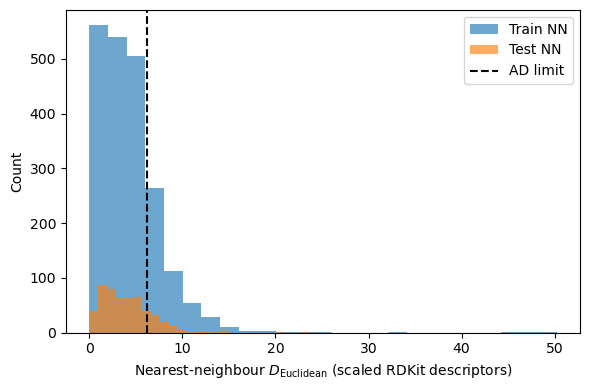

In [6]:
ad_limit, nn_train, ad_scaler = compute_ad(X_tr)
in_ad, nn_test = apply_ad(X_tr, X_ts, ad_limit, ad_scaler)

pred_table = test_df[["chembl_id", "smiles", "scaffold", "y"]].rename(columns={"y": "pchembl_obs"}).copy()
pred_table["in_AD"] = in_ad
pred_table["D_Euclidean"] = nn_test
pred_table.to_csv(MODEL_DIR / "test_predictions.csv", index=False)

print(f"Train NN D_Euclidean (scaled): {nn_train.mean():.3f} ± {nn_train.std():.3f}")
print(f"AD limit (mean + {AD_Z}*SD): {ad_limit:.3f}")
print(f"Test compounds similar to training space: {in_ad.mean():.3f} ({in_ad.sum()}/{len(in_ad)})")
print("in-AD = nearest-neighbour Euclidean distance in the scaled RDKit descriptor space, not a reliability certificate.")

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(nn_train, bins=25, alpha=0.65, label="Train NN")
ax.hist(nn_test, bins=25, alpha=0.65, label="Test NN")
ax.axvline(ad_limit, color="black", ls="--", label="AD limit")
ax.set_xlabel(r"Nearest-neighbour $D_{\mathrm{Euclidean}}$ (scaled RDKit descriptors)")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()


## 5. CatBoost

Trees do not need scaling. Search space covers depth, learning rate, L2, leaf size and boosting rounds. Each trial is scored by mean 5-fold R² with median pruning.


CatBoost: best CV R2 = 0.5394
Best params: {'depth': 8, 'learning_rate': 0.04949728149449648, 'l2_leaf_reg': 1.334109043935115, 'min_data_in_leaf': 14, 'iterations': 900}
model          CatBoost
R2_train       0.983577
RMSE_train      0.11311
Q2_CV          0.540344
RMSE_CV        0.598409
MAE_CV         0.437182
R2_ext         0.610591
RMSE_ext       0.557979
MAE_ext        0.411966
CCC_ext        0.751612
R2_ext_AD      0.672503
RMSE_ext_AD    0.521491
AD_coverage    0.805344


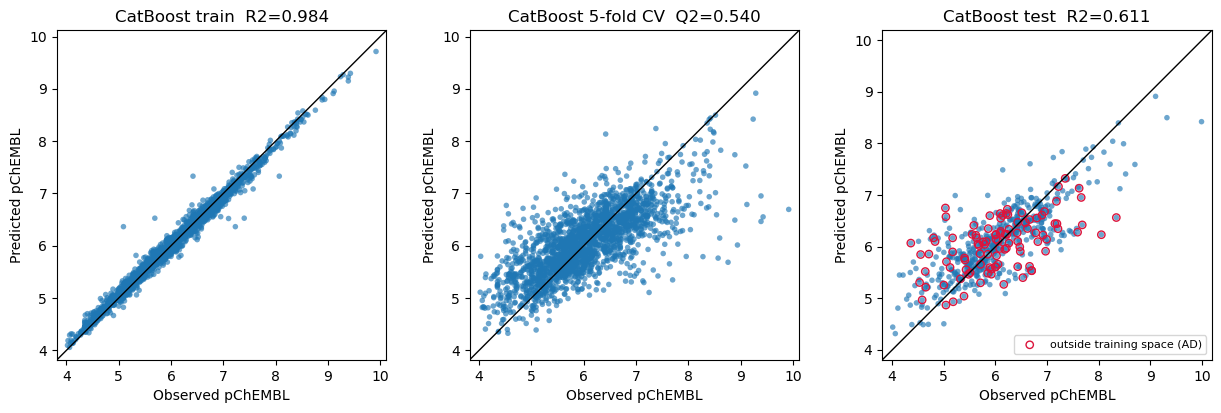

Updated models\RDKit\test_predictions.csv with pred_CatBoost


,chembl_id,pchembl_obs,pred_CatBoost,in_AD,D_Euclidean
0,CHEMBL5429446,4.01,4.441836,True,3.086965e+00
1,CHEMBL3605494,4.06,4.315598,True,4.768372e-07
2,CHEMBL5419832,4.11,4.809413,True,3.356685e+00
3,CHEMBL5571764,4.14,5.449884,True,5.131081e+00
4,CHEMBL3771210,4.21,5.449439,True,5.539262e+00


['models\\RDKit\\CatBoost_RDKit.pkl']

In [7]:
def objective_catboost(trial):
    params = {
        "depth": trial.suggest_int("depth", 4, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 12.0, log=True),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 1, 20),
        "iterations": trial.suggest_int("iterations", 200, 1000, step=100),
        "random_seed": SEED,
        "verbose": False,
        "loss_function": "RMSE",
        "allow_writing_files": False,
    }
    return cv_r2_pruned(trial, lambda: CatBoostRegressor(**params), X_tr, y_tr, cv_search)


studies["CatBoost"] = run_study("CatBoost", objective_catboost, N_TRIALS["CatBoost"])
best_cat = CatBoostRegressor(
    **studies["CatBoost"].best_params,
    random_seed=SEED,
    verbose=False,
    loss_function="RMSE",
    allow_writing_files=False,
)
cat_fit = {"verbose": False}
fitted["CatBoost"], row, preds["CatBoost"] = evaluate_model(
    "CatBoost", best_cat, X_tr, y_tr, X_ts, y_ts, in_ad, fit_params=cat_fit, cv_fit_params=cat_fit
)
results.append(row)
joblib.dump(fitted["CatBoost"], MODEL_DIR / "CatBoost_RDKit.pkl")


## 6. Support vector regression

RBF-SVR inside a `Pipeline` with `StandardScaler`, so scaling is fit only on each CV training fold. `C`, `gamma` and `epsilon` are searched on a log/linear scale covering the old grid and intermediate values.


SVR: best CV R2 = 0.4910
Best params: {'C': 8.067748577483462, 'gamma': 0.01675609019077191, 'epsilon': 0.06606503057347482}
model               SVR
R2_train       0.971057
RMSE_train      0.15016
Q2_CV          0.492033
RMSE_CV        0.629071
MAE_CV         0.455393
R2_ext         0.582895
RMSE_ext        0.57748
MAE_ext        0.422499
CCC_ext        0.752006
R2_ext_AD      0.645181
RMSE_ext_AD    0.542809
AD_coverage    0.805344


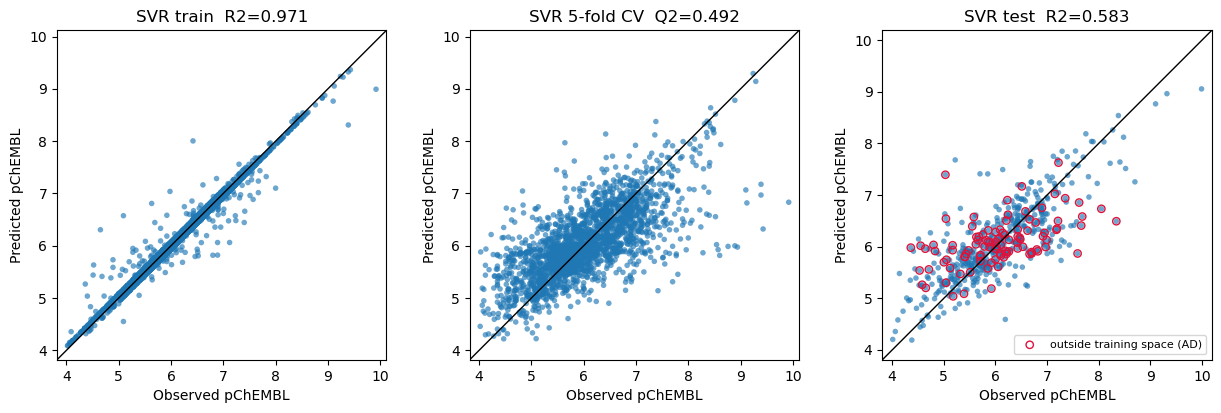

Updated models\RDKit\test_predictions.csv with pred_SVR


,chembl_id,pchembl_obs,pred_SVR,in_AD,D_Euclidean
0,CHEMBL5429446,4.01,4.202707,True,3.086965e+00
1,CHEMBL3605494,4.06,4.356392,True,4.768372e-07
2,CHEMBL5419832,4.11,4.580077,True,3.356685e+00
3,CHEMBL5571764,4.14,5.479919,True,5.131081e+00
4,CHEMBL3771210,4.21,4.749751,True,5.539262e+00


['models\\RDKit\\SVM_RDKit.pkl']

In [8]:
def make_svr(C, gamma, epsilon):
    return Pipeline(
        [
            ("scaler", StandardScaler()),
            ("svr", SVR(kernel="rbf", C=C, gamma=gamma, epsilon=epsilon, cache_size=500)),
        ]
    )


def objective_svr(trial):
    C = trial.suggest_float("C", 0.1, 1e4, log=True)
    gamma = trial.suggest_float("gamma", 1e-6, 1e-1, log=True)
    epsilon = trial.suggest_float("epsilon", 0.01, 0.5)
    return cv_r2_pruned(trial, lambda: make_svr(C, gamma, epsilon), X_tr, y_tr, cv_search)


studies["SVR"] = run_study("SVR", objective_svr, N_TRIALS["SVR"])
best_svr = make_svr(**studies["SVR"].best_params)
fitted["SVR"], row, preds["SVR"] = evaluate_model("SVR", best_svr, X_tr, y_tr, X_ts, y_ts, in_ad)
results.append(row)
joblib.dump(fitted["SVR"], MODEL_DIR / "SVM_RDKit.pkl")


## 7. Multi-layer perceptron

After filtering, the RDKit matrix is a few hundred continuous columns rather than 2048 sparse bits. Search is limited to 1–3 hidden layers, Adam, L2 and learning rate, with early stopping. Inputs are scaled inside the pipeline.


MLP: best CV R2 = 0.2900
Best params: {'n_layers': 2, 'n_units': 256, 'activation': 'relu', 'alpha': 2.9380279387035334e-05, 'learning_rate_init': 0.00020511104188433984}
model               MLP
R2_train       0.831435
RMSE_train     0.362381
Q2_CV           0.29309
RMSE_CV        0.742102
MAE_CV           0.5322
R2_ext         0.241852
RMSE_ext       0.778559
MAE_ext        0.526049
CCC_ext         0.61797
R2_ext_AD      0.566303
RMSE_ext_AD    0.600118
AD_coverage    0.805344


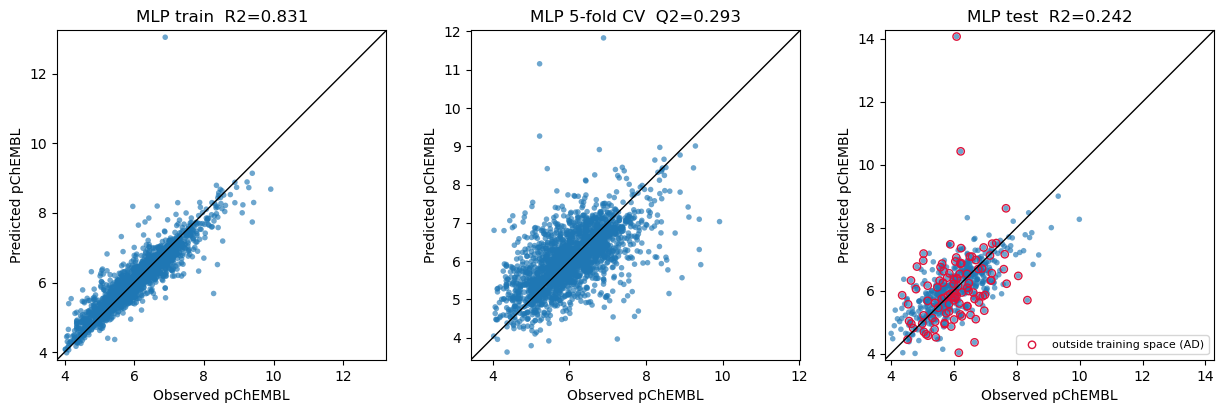

Updated models\RDKit\test_predictions.csv with pred_MLP


,chembl_id,pchembl_obs,pred_MLP,in_AD,D_Euclidean
0,CHEMBL5429446,4.01,4.641270,True,3.086965e+00
1,CHEMBL3605494,4.06,4.471956,True,4.768372e-07
2,CHEMBL5419832,4.11,4.884650,True,3.356685e+00
3,CHEMBL5571764,4.14,5.380120,True,5.131081e+00
4,CHEMBL3771210,4.21,5.104491,True,5.539262e+00


['models\\RDKit\\MLPR_RDKit.pkl']

In [9]:
def make_mlp(n_layers, n_units, activation, alpha, learning_rate_init):
    return Pipeline(
        [
            ("scaler", StandardScaler()),
            (
                "mlp",
                MLPRegressor(
                    hidden_layer_sizes=tuple([n_units] * n_layers),
                    activation=activation,
                    alpha=alpha,
                    learning_rate_init=learning_rate_init,
                    solver="adam",
                    max_iter=400,
                    early_stopping=True,
                    validation_fraction=0.1,
                    n_iter_no_change=15,
                    random_state=SEED,
                ),
            ),
        ]
    )


def objective_mlp(trial):
    n_layers = trial.suggest_int("n_layers", 1, 3)
    n_units = trial.suggest_int("n_units", 32, 256, step=32)
    activation = trial.suggest_categorical("activation", ["relu", "tanh"])
    alpha = trial.suggest_float("alpha", 1e-5, 1e-2, log=True)
    lr = trial.suggest_float("learning_rate_init", 1e-4, 1e-2, log=True)
    return cv_r2_pruned(
        trial, lambda: make_mlp(n_layers, n_units, activation, alpha, lr), X_tr, y_tr, cv_search
    )


studies["MLP"] = run_study("MLP", objective_mlp, N_TRIALS["MLP"])
best_mlp = make_mlp(**studies["MLP"].best_params)
fitted["MLP"], row, preds["MLP"] = evaluate_model("MLP", best_mlp, X_tr, y_tr, X_ts, y_ts, in_ad)
results.append(row)
joblib.dump(fitted["MLP"], MODEL_DIR / "MLPR_RDKit.pkl")


## 8. k-nearest neighbors

`n_neighbors`, `weights` and distance metric are optimized. Features are scaled inside a `Pipeline` because RDKit descriptors have incompatible units. Jaccard is omitted (it is for binary fingerprints). Predictions always use `X_ts`.


kNN: best CV R2 = 0.4691
Best params: {'n_neighbors': 8, 'weights': 'distance', 'metric': 'cosine'}
model               kNN
R2_train       0.995567
RMSE_train     0.058768
Q2_CV          0.470141
RMSE_CV        0.642483
MAE_CV         0.463041
R2_ext         0.572035
RMSE_ext        0.58495
MAE_ext        0.426744
CCC_ext        0.741786
R2_ext_AD      0.639871
RMSE_ext_AD    0.546855
AD_coverage    0.805344


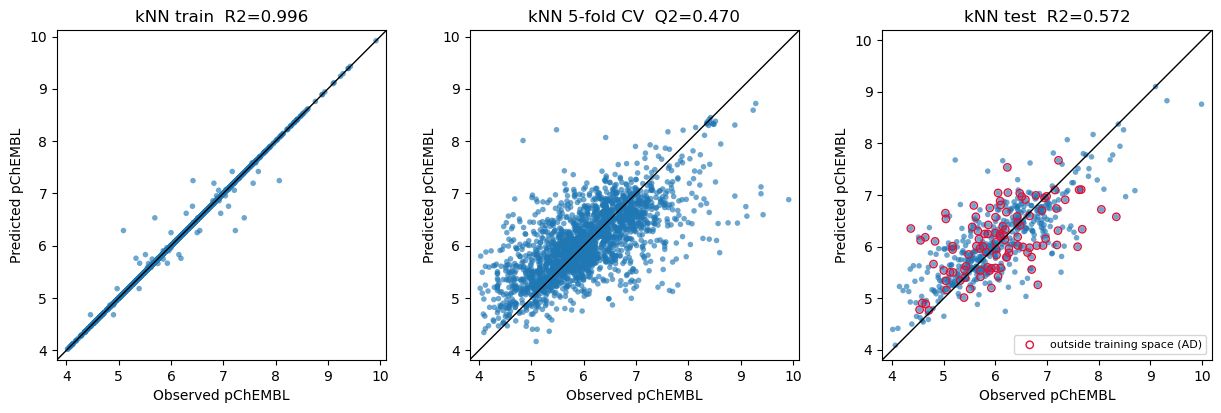

Updated models\RDKit\test_predictions.csv with pred_kNN


,chembl_id,pchembl_obs,pred_kNN,in_AD,D_Euclidean
0,CHEMBL5429446,4.01,4.396921,True,3.086965e+00
1,CHEMBL3605494,4.06,4.090000,True,4.768372e-07
2,CHEMBL5419832,4.11,4.418176,True,3.356685e+00
3,CHEMBL5571764,4.14,5.227985,True,5.131081e+00
4,CHEMBL3771210,4.21,5.149162,True,5.539262e+00


['models\\RDKit\\kNN_RDKit.pkl']

In [10]:
def make_knn(n_neighbors, weights, metric):
    return Pipeline(
        [
            ("scaler", StandardScaler()),
            ("knn", KNeighborsRegressor(n_neighbors=n_neighbors, weights=weights, metric=metric)),
        ]
    )


def objective_knn(trial):
    n_neighbors = trial.suggest_int("n_neighbors", 1, 31)
    weights = trial.suggest_categorical("weights", ["uniform", "distance"])
    metric = trial.suggest_categorical("metric", ["euclidean", "manhattan", "cosine"])
    return cv_r2_pruned(trial, lambda: make_knn(n_neighbors, weights, metric), X_tr, y_tr, cv_search)


studies["kNN"] = run_study("kNN", objective_knn, N_TRIALS["kNN"])
best_knn = make_knn(**studies["kNN"].best_params)
fitted["kNN"], row, preds["kNN"] = evaluate_model("kNN", best_knn, X_tr, y_tr, X_ts, y_ts, in_ad)
results.append(row)
joblib.dump(fitted["kNN"], MODEL_DIR / "kNN_RDKit.pkl")


## 9. Model comparison

Metrics are rounded to two decimals to match the manuscript table: training R²/RMSE, 5-fold Q²cv/RMSE, external Q²test/RMSE (all test compounds), AD coverage (Cov), Q²test/RMSE for compounds inside the applicability domain, and a Tropsha-style validity flag (`valid_tropsha`: Q² > 0.5, R²_ext > 0.6, |R²_ext − Q²| < 0.3).

If the notebook kernel was restarted, metrics are loaded from `models/RDKit/metrics_summary.csv` so models do not need to be retrained.


Loaded cached metrics from models\RDKit\metrics_summary.csv


,R2,RMSE,Q2cv,RMSE,Q2test,RMSE,Cov,Q2test,RMSE,valid_tropsha
model,,,,,,,,,,
CatBoost,0.98,0.11,0.54,0.60,0.61,0.56,0.81,0.67,0.52,True
SVM,0.97,0.15,0.49,0.63,0.58,0.58,0.81,0.65,0.54,False
MLP,0.83,0.36,0.29,0.74,0.24,0.78,0.81,0.57,0.60,False
kNN,1.00,0.06,0.47,0.64,0.57,0.58,0.81,0.64,0.55,False


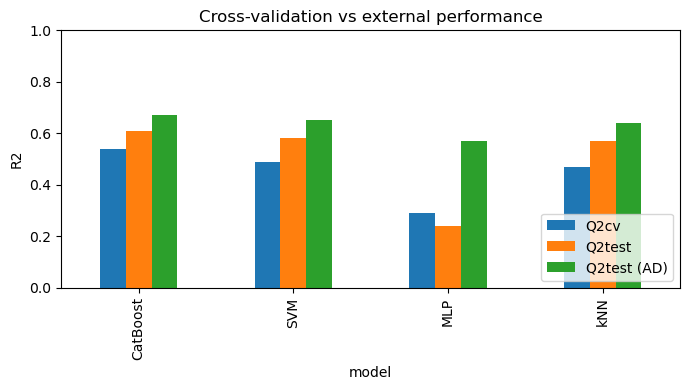

Best single model by external R2: CatBoost


In [2]:
metrics_path = MODEL_DIR / "metrics_summary.csv"

if "results" in globals() and results:
    summary = pd.DataFrame(results).set_index("model")
elif metrics_path.is_file():
    summary = pd.read_csv(metrics_path, index_col="model")
    print(f"Loaded cached metrics from {metrics_path}")
else:
    raise RuntimeError("No metrics in memory and no cached metrics_summary.csv found.")

summary = summary.drop(index=["Consensus"], errors="ignore")
summary["valid_tropsha"] = (
    (summary["Q2_CV"] > 0.5)
    & (summary["R2_ext"] > 0.6)
    & ((summary["R2_ext"] - summary["Q2_CV"]).abs() < 0.3)
)

TABLE_COLS = [
    "R2_train",
    "RMSE_train",
    "Q2_CV",
    "RMSE_CV",
    "R2_ext",
    "RMSE_ext",
    "AD_coverage",
    "R2_ext_AD",
    "RMSE_ext_AD",
]
TABLE_HEADERS = [
    "R2",
    "RMSE",
    "Q2cv",
    "RMSE",
    "Q2test",
    "RMSE",
    "Cov",
    "Q2test",
    "RMSE",
]
DISPLAY_NAMES = {"SVR": "SVM"}

table = summary[TABLE_COLS].copy()
table.index = table.index.map(lambda name: DISPLAY_NAMES.get(name, name))
table.columns = TABLE_HEADERS
table = table.round(2)
table["valid_tropsha"] = summary["valid_tropsha"].values

display(table)

fig, ax = plt.subplots(figsize=(7, 4))
summary[["Q2_CV", "R2_ext", "R2_ext_AD"]].round(2).rename(
    index=DISPLAY_NAMES,
    columns={"Q2_CV": "Q2cv", "R2_ext": "Q2test", "R2_ext_AD": "Q2test (AD)"},
).plot(kind="bar", ax=ax)
ax.set_ylabel("R2")
ax.set_ylim(0, 1)
ax.set_title("Cross-validation vs external performance")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

best_name = summary["R2_ext"].idxmax()
print("Best single model by external R2:", DISPLAY_NAMES.get(best_name, best_name))

table.to_csv(metrics_path)
if "studies" in globals() and studies:
    joblib.dump({k: v.best_params for k, v in studies.items()}, MODEL_DIR / "best_params.pkl")
    joblib.dump(studies, MODEL_DIR / "optuna_studies.pkl")


## 10. Y-randomization

`permutation_test_score` shuffles the training endpoint and repeats CV. A real structure–activity relationship should give a high true Q² and a near-zero (or negative) mean randomized score with a small p-value.


In [13]:
y_rand_rows = []
for name, est in fitted.items():
    perm_kwargs = {}
    if name == "CatBoost":
        perm_kwargs["params"] = {"verbose": False}
    score, perm_scores, pvalue = permutation_test_score(
        clone(est),
        X_tr,
        y_tr,
        cv=cv_final,
        scoring="r2",
        n_permutations=N_PERMUTATIONS,
        n_jobs=1 if name == "CatBoost" else -1,
        random_state=SEED,
        **perm_kwargs,
    )
    y_rand_rows.append(
        {
            "model": name,
            "true_Q2": score,
            "y_rand_mean": float(np.mean(perm_scores)),
            "y_rand_std": float(np.std(perm_scores)),
            "p_value": float(pvalue),
        }
    )
    print(
        f"{name}: true Q2 = {score:.3f}, "
        f"Y-randomization = {np.mean(perm_scores):.3f} ± {np.std(perm_scores):.3f}, "
        f"p = {pvalue:.4f}"
    )

y_rand = pd.DataFrame(y_rand_rows).set_index("model")
display(y_rand.round(4))
y_rand.round(4).to_csv(MODEL_DIR / "y_randomization.csv")


CatBoost: true Q2 = 0.539, Y-randomization = -0.198 ± 0.022, p = 0.0476
SVR: true Q2 = 0.491, Y-randomization = -0.411 ± 0.036, p = 0.0476
MLP: true Q2 = 0.290, Y-randomization = -0.429 ± 0.031, p = 0.0476
kNN: true Q2 = 0.469, Y-randomization = -0.264 ± 0.026, p = 0.0476


,true_Q2,y_rand_mean,y_rand_std,p_value
model,,,,
CatBoost,0.5394,-0.1980,0.0221,0.0476
SVR,0.4910,-0.4111,0.0365,0.0476
MLP,0.2900,-0.4294,0.0313,0.0476
kNN,0.4691,-0.2642,0.0257,0.0476
